In [1]:
import os,sys

# Set the path to the parent directory manually
parent_dir = os.path.abspath("../..")
if parent_dir not in sys.path:
    sys.path.append(parent_dir)
    
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
import pkg_resources
from datetime import datetime as dt, timedelta
from datetime import datetime
import glob
from netCDF4 import Dataset
from util.wrf_process import (calc_derive, object_tracking, read_and_write, to_polar)
from util.ml_framework import (cnn, vae)
from wrf import (to_np, getvar, smooth2d, get_cartopy, cartopy_xlim,
                 cartopy_ylim, latlon_coords, interplevel, ll_to_xy)
import gc,pickle
from tqdm import tqdm
import xarray as xr
from natsort import natsorted
from util.ml_preprocess import data_preproc
#from vae3d import VAEEncoder, VAEDecoder, VAE, elbo_loss, weights_init
import optuna
import random,math
import proplot as plot
import pyart

/glade/derecho/scratch/ihtam/tmp/ipykernel_23570/1132177199.py:12: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources
/glade/work/ihtam/miniconda3/envs/myenv/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



In [2]:
# Track path
track_memb03 = xr.open_dataset('/glade/work/ihtam/storage/track_avor_850-600.nc')
ctrl_files = sorted(glob.glob("/glade/derecho/scratch/ihtam/haiyan/ctrl/wrfout_d02_2013-11-0*"))[:29]
miaxi2x_files = sorted(glob.glob("/glade/campaign/univ/uokl0049/haiyan_pattern/minus_2idealaxi/wrfout_d02_2013-11-0*"))[:29]
aiaxi2x_files = sorted(glob.glob("/glade/campaign/univ/uokl0049/haiyan_pattern/add_2idealaxi/wrfout_d02_2013-11-0*"))[:29]
mdd_p2f_files =sorted(glob.glob("/glade/campaign/univ/uokl0049/haiyan_pattern/minus_2DDp_pareto2/wrfout_d02_2013-11-0*"))[:29]
dd_p2f_files = sorted(glob.glob("/glade/derecho/scratch/ihtam/haiyan/add_2DDp_pareto2/wrfout_d02_2013-11-0*"))[:29]

In [3]:
# --- 1. ProPlot Configuration for Aesthetic ---
# Resetting to ProPlot defaults is good practice, then apply specific styles.
plot.rc.reset() 

# Set global font size, family, and math font
plot.rc.update({
    'font.size': 11.5,          # Matched target aesthetic
    'font.name': 'DejaVu Sans', # A common, clean sans-serif like the target image
    'mathtext.fontset': 'dejavusans', # Match math font to text font
    'grid.alpha': 0.7,        # Make grid lines slightly transparent
    'grid.linewidth': 1.0,    # Thicker grid lines
    'grid.linestyle': '--',   # Dotted/dashed grid
    'grid.color': 'lightgray', # Light grey grid color
    'linewidth': 1.5,         # Default line width for spines and major ticks
    'ticklen': 5,             # Tick length
    'tickdir': 'out',         # Ticks point outward (or 'in' if preferred)
    'axes.spines.right': False, # Remove right spine
    'axes.spines.top': False,   # Remove top spine
    'axes.titlepad': 5.0,     # Adjust title padding if needed
    'legend.framealpha': 1.0,   # Opaque legend background
    'legend.facecolor': 'white',# White legend background
    'legend.edgecolor': '0.8',  # Light gray legend border
    'legend.fontsize': 9,      # Legend font size
    'legend.fancybox': True,    # Rounded corners for legend
# --- White Background Settings ---
    'figure.facecolor': 'white', # Set the color of the canvas/figure outside the axes
    'axes.facecolor': 'white',   # Set the color of the plotting area/axes background
})

/glade/derecho/scratch/ihtam/tmp/ipykernel_23570/1532609950.py:6: ProplotWarning: rc setting 'linewidth' was renamed to 'meta.width' in version 0.8.
  plot.rc.update({


In [6]:
def calc_twovort(ncfile,h1,h2):
    # Read in AVOR
    ctrl_avo = getvar(ncfile,'avo')
    # Read in Height
    ctrl_z = getvar(ncfile,'height_agl')
    # Interpolate AVOR to Height level
    ctrl_ht_a = interplevel(ctrl_avo, ctrl_z, h1)
    ctrl_ht_b = interplevel(ctrl_avo, ctrl_z, h2)
    return ctrl_ht_a, ctrl_ht_b
    
def extract_onevar_loop(fileslist,track,dr,twoD,varname,interplv):
    varouts = []
    for i in tqdm(range(len(fileslist))):
        nc_ctrl = Dataset(fileslist[i])
        # Target location
        target_lat = track_memb03['clat'][12+i]
        target_lon = track_memb03['clon'][12+i]
        # Compute track indices
        ix, iy = ll_to_xy(nc_ctrl, target_lat, target_lon, timeidx=0) #x, y
        if twoD:
            ctrl_slp = getvar(nc_ctrl,varname)
            varouts.append(ctrl_slp[int(iy)-dr:int(iy)+dr,int(ix)-dr:int(ix)+dr])
            del ctrl_slp
            gc.collect()
        else:
            ctrl_avo = getvar(nc_ctrl,varname)
            ctrl_p = getvar(nc_ctrl,'pressure')
            ctrl_ht_a = interplevel(ctrl_avo, ctrl_p, interplv)
            varouts.append(ctrl_ht_a[int(iy)-dr:int(iy)+dr,int(ix)-dr:int(ix)+dr])
            del ctrl_ht_a
            gc.collect()
    return varouts

In [8]:
ctrl_mdbz = extract_onevar_loop(ctrl_files[:28],track_memb03,200,True,'ctt',None)
#ctrl_rthratlw = extract_onevar_loop(ctrl_files[:15],track_memb03,200,'RTHRATLW',600)

100%|██████████| 28/28 [03:58<00:00,  8.52s/it]


In [10]:
from matplotlib.colors import LinearSegmentedColormap
def white_to_black_to_transparent(name="wb2t", n=256, split=0.72):
    """
    split: fraction of the colormap that is the opaque white->black ramp.
           remaining part is black with alpha fading to 0.
    """
    x = np.linspace(0, 1, n)
    rgba = np.zeros((n, 4), dtype=float)

    # RGB: grayscale from white->black until split, then stay black
    t = np.clip(x / split, 0, 1)
    gray = 1.0 - t
    rgba[:, 0] = gray
    rgba[:, 1] = gray
    rgba[:, 2] = gray

    # Alpha: 1 until split, then linearly fade to 0
    a = np.ones(n)
    fade = x >= split
    a[fade] = 1.0 - (x[fade] - split) / (1.0 - split)
    rgba[:, 3] = np.clip(a, 0, 1)

    return LinearSegmentedColormap.from_list(name, rgba)

cmap = white_to_black_to_transparent()


In [33]:
for i in range(27):
    plt.pcolormesh(ctrl_mdbz[i],cmap='bone_r')#'pyart_langrainbow12')
    plt.title(f'CTRL; Hour{12+i}')
    plt.colorbar(label='Cloud Top Temperature ($^o$C)')
    plt.savefig(f'./pics/animation/CTRL_{12+i}.png',dpi=300)
    plt.close()

In [20]:
dd_p2f_mdbz = extract_onevar_loop(dd_p2f_files[:28],track_memb03,200,True,'ctt',None)
#dd_p2f_rthratlw = extract_onevar_loop(dd_p2f_files[:15],track_memb03,200,'RTHRATLW',600)

100%|██████████| 28/28 [03:58<00:00,  8.50s/it]


In [31]:
for i in range(27):
    plt.pcolormesh(dd_p2f_mdbz[i],cmap='bone_r')#'pyart_langrainbow12')
    plt.title(f'add_2DD; Hour{12+i}')
    plt.colorbar(label='Cloud Top Temperature ($^o$C)')
    plt.savefig(f'./pics/animation/add_2DD_{12+i}.png',dpi=300)
    plt.close()

In [28]:
mdd_p2f_mdbz = extract_onevar_loop(mdd_p2f_files[:28],track_memb03,200,True,'ctt',None)

100%|██████████| 28/28 [03:59<00:00,  8.54s/it]


In [32]:
for i in range(27):
    plt.pcolormesh(mdd_p2f_mdbz[i],cmap='bone_r')#'pyart_langrainbow12')
    plt.title(f'minus_2DD; Hour{12+i}')
    plt.colorbar(label='Cloud Top Temperature ($^o$C)')
    plt.savefig(f'./pics/animation/minus_2DD_{12+i}.png',dpi=300)
    plt.close()

In [12]:
aiaxi2x_mdbz = extract_onevar_loop(aiaxi2x_files[:15],track_memb03,200,'mdbz')

100%|██████████| 15/15 [01:43<00:00,  6.89s/it]


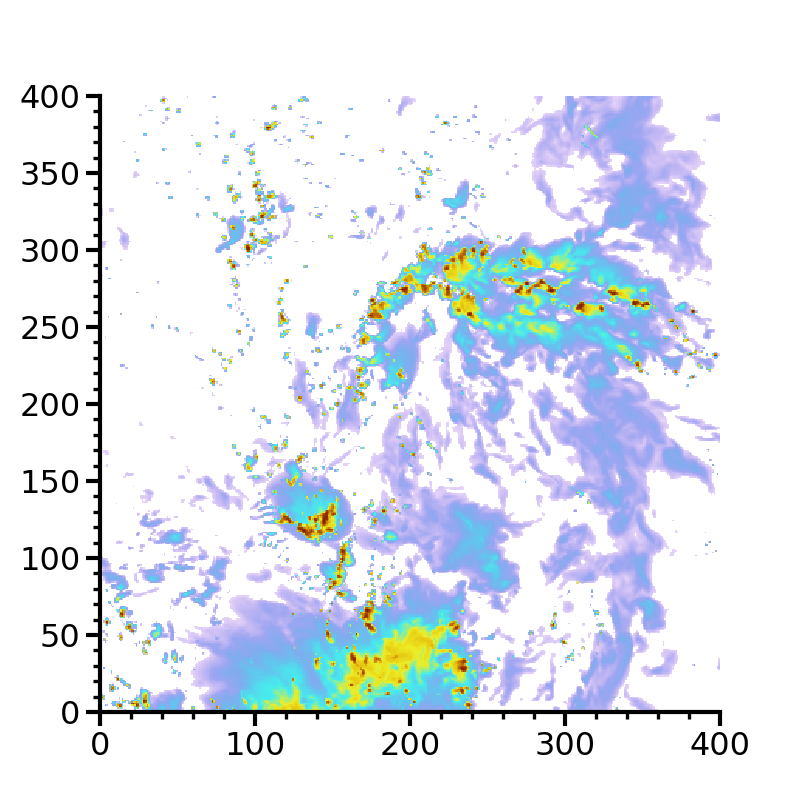

In [14]:
plt.pcolormesh(np.ma.masked_less(mdd_p2f_mdbz[-1],5),cmap='pyart_langrainbow12')

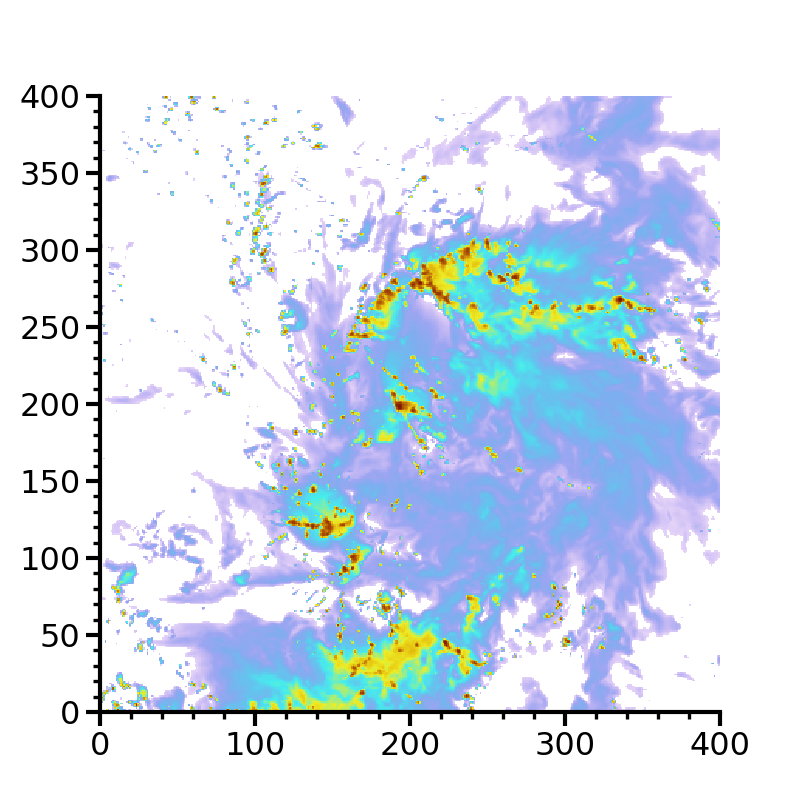

In [16]:
plt.pcolormesh(np.ma.masked_less(aiaxi2x_mdbz[-1],1),cmap='pyart_langrainbow12')